## Assignment 2: $k$ Nearest Neighbor

### Do any four.

Q1. Please answer the following questions

1. What is the difference between regression and classification?

Classification is for categorical variables: for an observation, we try to assign them to a category given the values of their other variables. Regression, by contrast, is for continuous variables: for an observation, we try to predict their value given the values of their other variables.

2. What is a confusion table/matrix? What does it help us understand about a model's performance?

A confusion matrix is when you cross-tab the true values of a variable with the ones you predict via classification. This lets us understand how accurate a model is.

3. What is Accuracy? Why might it not be entirely sufficient to evaluate a classifer's predictive performance?

Accuracy (in classification) is what % of cases did the model predict correctly? It gives you a single numerical value that summarizes your confusion matrix. This may not be sufficient to evaluate the model's performance because it is calculated using the confusion matrix, which only includes observations you've already seen. As such, accuracy can't describe how good a model is with previously unseen observations.

4. What does the root mean squared error quantify about a particular model?

The root mean square error in a regression tells us the average of the distance between the predicted value and true value for all observations.

5. What are overfitting and underfitting?

Overfitting is when a model is too sensitive to minute variations in data, i.e. has high variance. In a KNN context, this is when we have a very small k, making the model overly sensitive to a handful of data points. Underfitting, meanwhile, is when the model is too simple to capture underlying patterns in data/not sensitive enough, i.e. has low variance. In KNN, this is when we have a very large k -- meaning the model just takes the plurality class label in an immense neighborhood, even if that label is in reality completely unrelated to your other variables' values.

6. Why does splitting the data into training and testing sets, and choosing  𝑘  by evaluating accuracy or RMSE on the test set, improve model performance?

Having training and test sets allows you to pick a better k because the model isn't evaluated on data it has seen before (training data), but rather on the test data it hasn't yet seen -- approximating using the model for new cases we haven't yet observed.

7. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

Hard classification (reporting a single class label) is good for cases when you just need one single label to run with, but bad when there are two or more nearly-equally likely labels. Soft classification (distribution of labels) is good because it shows you how certain the model is of its predictions, which can provide very helpful context -- e.g. if a model is saying only 8% A, 7% B, 6% C, we know we're not very sure of the prediction at all and won't present findings as strong. However, soft classification is weak whenever you need just one single label to run with.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

In [2]:
# Get data
! git clone https://github.com/ds4e/get_data
%run ./get_data/get_data.py

# Import libraries
import pandas as pd
import seaborn as sns

fatal: destination path 'get_data' already exists and is not an empty directory.


1. Load the data. Perform some EDA, summarizing the target label and the relationships between the features (e.g. scatterplots, describe tables).

In [3]:
land_mines = pd.read_csv ("data/land_mines.csv")
land_mines.head()

,voltage,height,soil,mine_type
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1


In [4]:
land_mines["mine_type"].value_counts()

,count
mine_type,
1,71
2,70
3,66
4,66
5,65


<Axes: xlabel='mine_type', ylabel='height'>

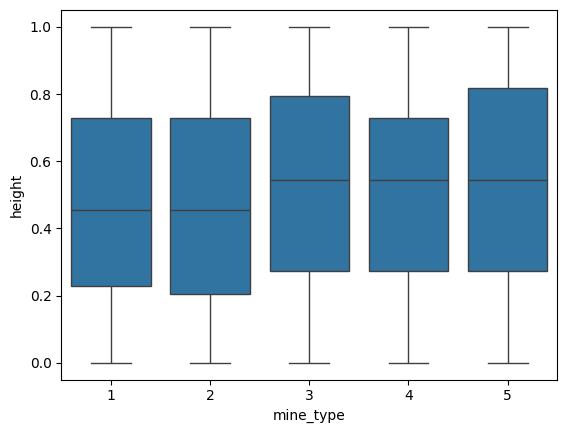

In [5]:
sns.boxplot(x=land_mines["mine_type"], y=land_mines["height"])

<Axes: xlabel='mine_type', ylabel='voltage'>

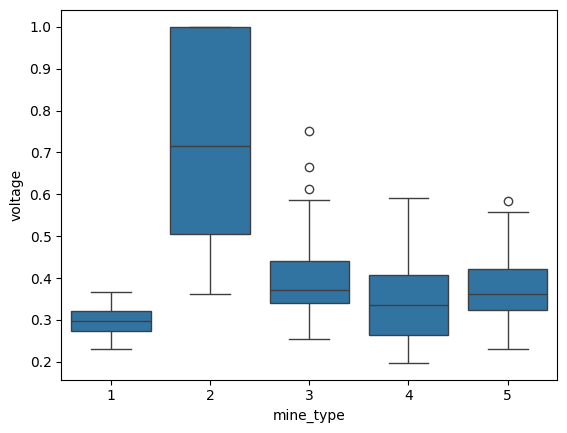

In [6]:
sns.boxplot(x=land_mines["mine_type"], y=land_mines["voltage"])

<Axes: ylabel='Density'>

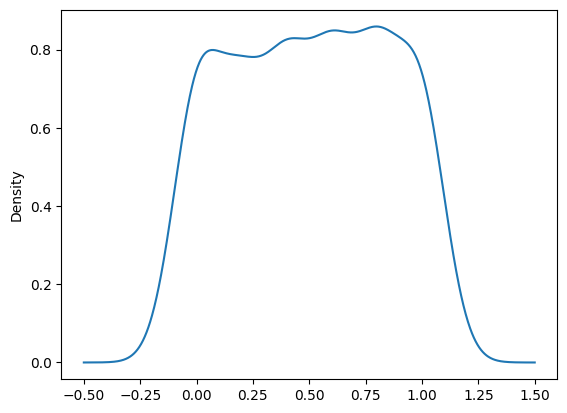

In [7]:
land_mines['soil'].plot.kde()

<Axes: xlabel='height', ylabel='soil'>

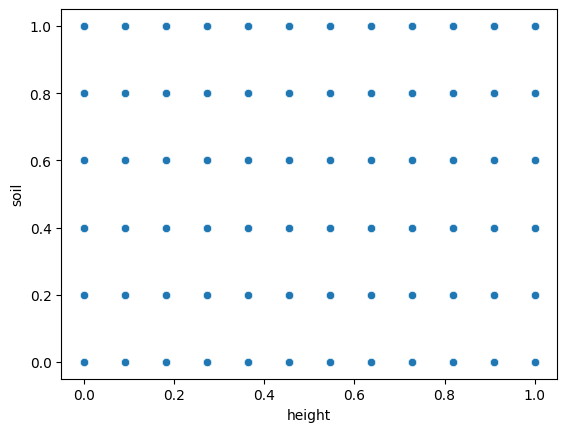

In [8]:
sns.scatterplot(x=land_mines['height'], y=land_mines['soil'])

2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)

In [9]:
land_mines = land_mines.sample(frac=1, random_state = 100)
test_size = int( .5 * len(land_mines) )
land_mines_test = land_mines.iloc[:test_size,:].reset_index(drop=True)
land_mines_train = land_mines.iloc[test_size:,:].reset_index(drop=True)

3. Build a $k$-NN classifier. Explain how you select $k$.

In [10]:
# Setup: import packages, minmax functions

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

def minmax(x):
    u = (x-min(x))/(max(x)-min(x))
    return u

In [11]:
# Set outcome vars, covariates, and normalize x into u
# For train set:

y_train = land_mines_train['mine_type'] # Set out outcome/target
ctrl_list = [ 'height', 'voltage', 'soil'] # List of control variables
x_train = land_mines_train.loc[:, ctrl_list] # Set our covariates/features
u_train = scaler.fit_transform(x_train)

# For test set:
y_test = land_mines_test['mine_type'] # Set out outcome/target
ctrl_list = [ 'height', 'voltage', 'soil'] # List of control variables
x_test = land_mines_test.loc[:, ctrl_list] # Set our covariates/features
u_test = scaler.transform(x_test)

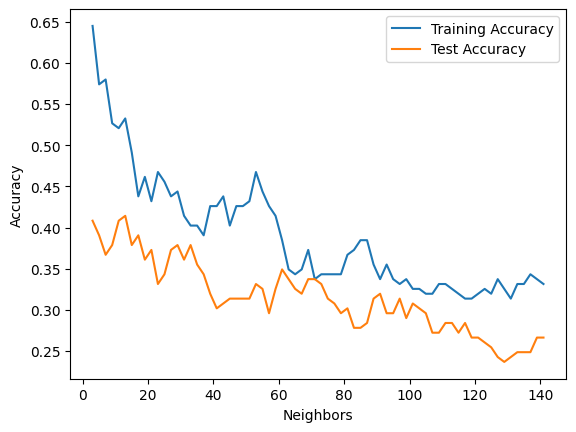

The k with the highest test accuracy is 13


In [12]:
from sklearn.metrics import mean_squared_error as mse
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

k_grid = np.array([ (2*k+3) for k in range(0,70)]) # Odd number grid
test_accuracies = []
train_accuracies = []
for k in k_grid: # For each candidate value of k...
    model = KNeighborsClassifier(n_neighbors = k) # Create a model instance
    model = model.fit(u_train,y_train) # Fit the model
    y_hat = model.predict(u_test) # Predict values
    test_acc = model.score(u_test,y_test) # Compute test accuracy
    train_acc = model.score(u_train,y_train) # Compute training accuracy
    test_accuracies.append(test_acc) # Save test results
    train_accuracies.append(train_acc) # Save training results

sns.lineplot(x=k_grid,y=train_accuracies,label='Training Accuracy').set(xlabel='Neighbors',ylabel='Accuracy')
sns.lineplot(x=k_grid,y=test_accuracies,label='Test Accuracy')
plt.show()

# Pick highest test accuracy k as k-star:
index_star = np.argmax( test_accuracies )
k_star = k_grid[index_star]

print ("The k with the highest test accuracy is " + str(k_star))

4. Print a confusion table for your best model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?

In [13]:
model = KNeighborsClassifier(n_neighbors = k_star) # Create a model instance
model = model.fit(u_train, y_train) # Fit the model
y_hat = model.predict(u_test)

# Confusion matrix with clear row labels to be readable:
import pandas as pd
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_hat)

labels = sorted(y_test.unique())
cm_df = pd.DataFrame(cm, index=labels, columns=labels)
cm_norm = cm_df.div(cm_df.sum(axis=1), axis=0)

cm_df

,1,2,3,4,5
1,25,0,10,0,3
2,0,22,6,3,4
3,2,3,11,1,16
4,15,0,9,4,7
5,7,2,11,0,8


In [14]:

# Calculate accuracy:
print("The accuracy of this model is " + str(model.score(u_test, y_test)))

The accuracy of this model is 0.41420118343195267


In [15]:
# Interpretation: This model is not very accurate (accuracy: ~0.41). It is only
# accurate at predicting type 2 landmines (~81.4% accuracy, 18.6% false pos rate). However, it only predicted
# ~22/35 type 2 mines (on my run) as type 2 -- a false negative rate of 37%.
# It is also not horrible with type 1 mines (~50% accuracy/50% false pos. rate, 33% false neg rate).

5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

In [16]:
# I would only advise someone to use this model as a "type 2 verifier,"
# with somewhat reasonable confidence that if something is predicted as a type 2 mine,
# it is actually a type 2 mine. However, the model will mislabel a lot of type 2 mines
# as other types (false negatives), so something being labeled as another type is by no means definite
# rejection of it being type 2.

**Q6.** This is a case study using $k$ nearest neighbor regression for imputation, using the `airbnb_hw.csv` data.

There are 30,478 observations, but only 22,155 ratings. We're going to build a kNN regressor to impute missing values. This is a common task, and illustrates one way you can use kNN in the future even when you have more advanced models available.

1. Load the `airbnb_hw.csv` data with Pandas. We're only going to use `Review Scores Rating`, `Price`, and `Beds`, so use `.loc` to column filter the dataframe to those variables.

In [17]:
airbnb = pd.read_csv("data/airbnb_hw.csv")
airbnb = airbnb.loc[:,['Review Scores Rating', 'Price', 'Beds']]

2. Set use `.isnull()` and `.loc` to select the subset of the dataframe with missing review values. Set those aside in a different dataframe. We'll make predictions about them later.

In [18]:
airbnb_null = airbnb.loc[airbnb['Review Scores Rating'].isnull(),:]
airbnb_null

,Review Scores Rating,Price,Beds
0,NaN,145,1.0
1,NaN,37,1.0
2,NaN,28,1.0
3,NaN,199,3.0
13,NaN,68,1.0
...,...,...,...
30473,NaN,300,5.0
30474,NaN,125,2.0
30475,NaN,80,1.0
30476,NaN,35,1.0


In [19]:
# Do some additional cleaning (typecast Price to int):
airbnb['Price'] = pd.to_numeric(airbnb['Price'].str.replace('$','').str.replace(',',''))
airbnb.dtypes

,0
Review Scores Rating,float64
Price,int64
Beds,float64


3. Use `df = df.dropna(axis = 0, how = 'any')` to eliminate any observations with missing values/NA's from the dataframe.

In [20]:
airbnb = airbnb.dropna(axis = 0, how = 'any')
airbnb.isna()

,Review Scores Rating,Price,Beds
4,False,False,False
5,False,False,False
6,False,False,False
7,False,False,False
8,False,False,False
...,...,...,...
30332,False,False,False
30347,False,False,False
30378,False,False,False
30404,False,False,False


4. For the complete cases, create a $k$-NN model that uses the variables `Price` and `Beds` to predict `Review Scores Rating`. How do you choose $k$? (Hint: Train/test split, iterate over reasonable values of $k$ and find a value that minimizes SSE on the test split using predictions from the training set.)

The k with the lowest MSE is 99


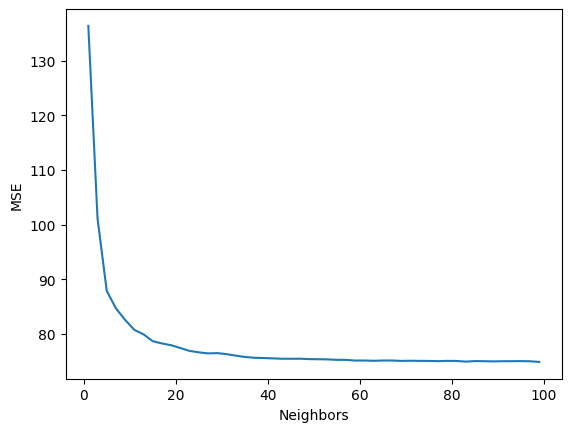

In [21]:
from sklearn.neighbors import KNeighborsRegressor
# Train test split
airbnb = airbnb.sample(frac=1, random_state = 100)
test_size = int( .5 * len(airbnb) ) # Set 50/50 train test split
airbnb_test = airbnb.iloc[:test_size,:].reset_index(drop=True)
airbnb_train = airbnb.iloc[test_size:,:].reset_index(drop=True)

# Set outcome vars, covariates, and normalize x into u
# For train set:

y_train = airbnb_train['Review Scores Rating'] # Set out outcome/target
ctrl_list = ['Price', 'Beds'] # List of control variables
x_train = airbnb_train.loc[:, ctrl_list] # Set our covariates/features
u_train = scaler.fit_transform(x_train)

# For test set:
y_test = airbnb_test['Review Scores Rating'] # Set out outcome/target
ctrl_list = ['Price', 'Beds'] # List of control variables
x_test = airbnb_test.loc[:, ctrl_list] # Set our covariates/features
u_test = scaler.transform(x_test)

# We will run a bunch of models and pick the k for which there is the least MSE:
k_grid = [ (2*k+1) for k in range(50) ] # Odd numbers from 1 to 101
mses = [] # List to save MSEs
for k in k_grid:
    model = KNeighborsRegressor(n_neighbors = k) # Create a model instance
    model = model.fit(u_train, y_train) # Fit the model
    y_hat = model.predict(u_test) # Predict values
    mses.append( mse(y_test, y_hat) ) # Compute and store MSE
sns.lineplot(x=k_grid, y=mses).set(ylabel='MSE', xlabel='Neighbors') # Plot MSE

# Pick the lowest k:
index_star = np.argmin( mses ) # Find minimizing index of mses
k_star = k_grid[index_star] # Find value of k at that index
print ("The k with the lowest MSE is " + str(k_star))

5. Predict the missing ratings.

In [22]:
model = KNeighborsRegressor(n_neighbors = k_star) # Create a model instance
model = model.fit(u_train, y_train) # Fit the model
x_null = airbnb_null.loc[:, ctrl_list] # Set our covariates/features

# Cleaning: Imputing NAs in 'Beds' with averages
x_null['Beds'] = x_null['Beds'].fillna(x_null['Beds'].mean())
# Cleaning: Make price numeric
x_null['Price'] = pd.to_numeric(x_null['Price'].str.replace('$','').str.replace(',',''))

u_null = scaler.transform(x_null)
airbnb_null['Review Scores Rating'] = model.predict(u_null) # Predict values

airbnb_null.head()

,Review Scores Rating,Price,Beds
0,94.565657,145,1.0
1,87.111111,37,1.0
2,86.888889,28,1.0
3,89.616162,199,3.0
13,91.282828,68,1.0


6. Do a kernel density plot of the training ratings and the predicted missing ratings. Do they look similar or not? Describe what you see.

(60.0, 110.0)

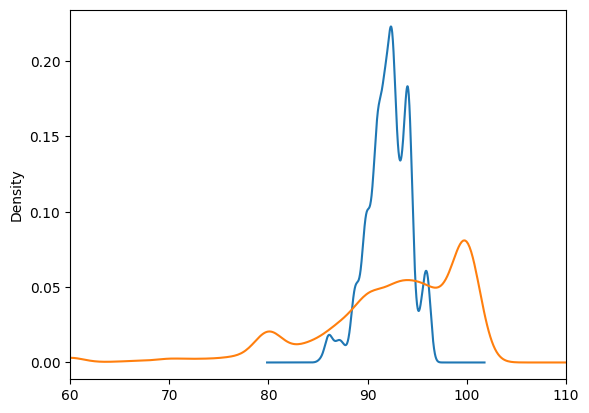

In [23]:
ax = airbnb_null['Review Scores Rating'].plot.kde()
y_train.plot.kde(ax=ax)

ax.set_xlim(60, 110)

# The ratings do not look similar: there is the same center
# around 95, but the predicted ratings are much tighter than the training ratings.

**Q7**. Let's do some very basic computer vision. We're going to import the MNIST handwritten digits data and use  𝑘 -NN to predict values (i.e. "see/read").

1. To load the data, run the following code in a chunk:

In [24]:
from keras.datasets import mnist
df = mnist.load_data('minst.db')
train,test = df
X_train, y_train = train
X_test, y_test = test

The y_test and y_train vectors, for each index i, tell you want number is written in the corresponding index in X_train[i] and X_test[i]. The value of X_train[i] and X_test[i], however, is a 28 × 28 array whose entries contain values between 0 and 256. Each element of the matrix is essentially a "pixel" and the matrix encodes a representation of a number. To visualize this, run the following code to see the first ten numbers:

7 

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0  84 185 159 151  60  36   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0 222 254 254 254 254 241 198 198 198 198 198 198 19

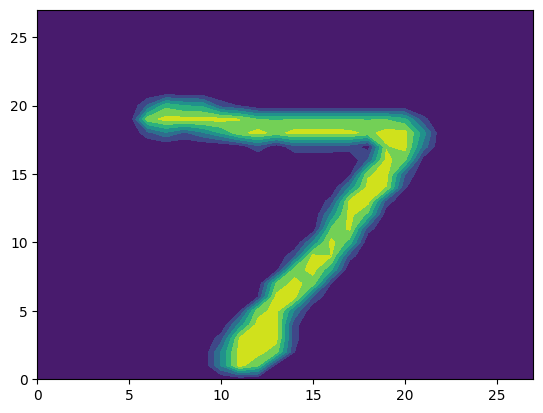

In [25]:
import matplotlib.pyplot as plt
import numpy as np
np.set_printoptions(edgeitems=30, linewidth=100000)
for i in range(1):
    print(y_test[i],'\n') # Print the label
    print(X_test[i],'\n') # Print the matrix of values
    plt.contourf(np.rot90(X_test[i].transpose())) # Make a contour plot of the matrix values
    plt.show()

2. What is the shape of `X_train` and `X_test`? What is the shape of `X_train[i]` and `X_test[i]` for each index `i`? What is the shape of `y_train` and `y_test`?

In [26]:
# Shape of X_train:
print(X_train.shape)
# There are 60,000 samples in X_train that are 28x28 matrices

# Shape of X_train[i]:
print(X_train[0].shape)
# Each sample is a 28x28 matrix

# Shape of X_test:
print(X_test.shape)
# There are 10,000 samples in X_test that are 28x28 matrices

# Shape of X_test[i]:
print(X_test[0].shape)
# Each sample is a 28x28 matrix

# Shape of y_train:
print(y_train.shape)
# There are 60,000 1D vectors, each corresponding perfectly to a X_train obs.

# Shape of y_test
print(y_test.shape)
# There are 10,000 1D vectors, each corresponding perfectly to a X_test obs.

(60000, 28, 28)
(28, 28)
(10000, 28, 28)
(28, 28)
(60000,)
(10000,)


3. Use Numpy's `.reshape()` method to covert the training and testing data from a list of matrix into an vector of features. So, `X_test[index].reshape((1,784))` will convert the $index$-th element of `X_test` into a $28\times 28=784$-length row vector of values, rather than a matrix. Turn `X_train` into an $N \times 784$ matrix $X$ that is suitable for scikit-learn's kNN classifier where $N$ is the number of observations and $784=28*28$ (you could use, for example, a `for` loop).

In [27]:
X_train_reshaped = []
X_test_reshaped = []

# Reshape X_train: Highly time-inefficient way to do this below but here goes
for img in X_train:
    X_train_reshaped.append(img.reshape(784))

X_train_reshaped = np.array(X_train_reshaped)

# Reshape X_test:
for img in X_test:
    X_test_reshaped.append(img.reshape(784))

X_test_reshaped = np.array(X_test_reshaped)

print(X_train_reshaped.shape)
print(X_test_reshaped.shape)

# Reshape y_test & y_train:
y_test = y_test.reshape(-1,1)
y_train = y_train.reshape(-1,1)

(60000, 784)
(10000, 784)


4. Use the reshaped `X_test` and `y_test` data to create a $k$-nearest neighbor classifier of digit. What is the optimal number of neighbors $k$? If you can't determine this, play around with different values of $k$ for your classifier.

In [29]:
# Unfortunately we will have to subsample to not have hours-long runtimes

import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

# Subsample for fast tuning
X_sub, _, y_sub, _ = train_test_split(
    X_train_reshaped, y_train,
    train_size=12000, stratify=y_train, random_state=0
)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_sub, y_sub,
    test_size=2000, stratify=y_sub, random_state=0
)

k_grid = [1,3,5,7,9,11,15,21,31,41]
test_accuracies = []
train_accuracies = []

for k in k_grid:
    print(f"k={k} ...", flush=True) # (just for my own sanity, print every time this runs so I can verify it's actually running
    model = KNeighborsClassifier(n_neighbors=k, n_jobs=-1, algorithm="brute") # We love minimal time complexity
    model.fit(X_tr, y_tr)
    train_accuracies.append(model.score(X_tr, y_tr))
    test_accuracies.append(model.score(X_val, y_val))

k_star = k_grid[int(np.argmax(test_accuracies))]
print("Best k:", k_star)

k=1 ...


/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


k=3 ...


/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


k=5 ...


...

k=31 ...


/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


k=41 ...


/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Best k: 3


5. For the optimal number of neighbors, how well does your predictor perform on the test set? Report the accuracy, compute a confusion matrix, and explain your findings.

In [39]:
model = KNeighborsClassifier(n_neighbors=k_star, n_jobs=-1, algorithm="brute")
model.fit(X_train_reshaped, y_train)
y_hat = model.predict(X_test_reshaped)

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Predicted: 7
True: [7]
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0  84 185 159 151  60  36   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0 222 254 254 254 254 241 198 198

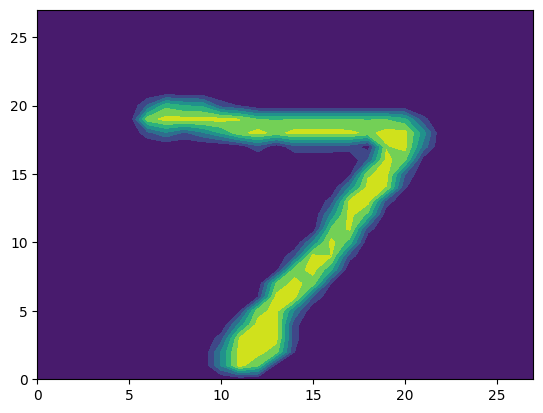

Predicted: 2
True: [2]
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 116 125 171 255 255 150  93   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0 169 253 253 253 253 253 253 218  30   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0 169 253 253 253 213 142 176 253 253 122   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0  52 250 253 210  32  12   0   6 206 253 140   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0  77 251 210  25   0   0   0 122 248 253  65   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0  31  18   0   0   0   0

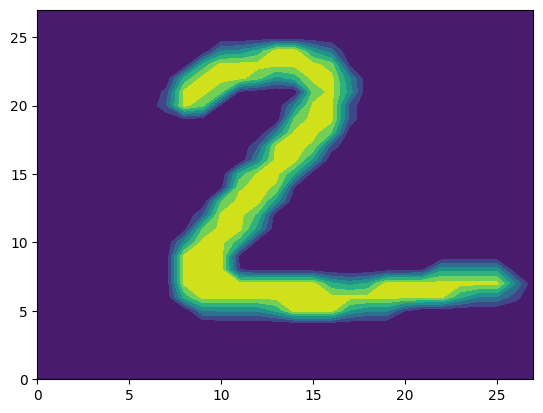

Predicted: 1
True: [1]
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  38 254 109   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  87 252  82   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 135 241   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  45 244 150   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0

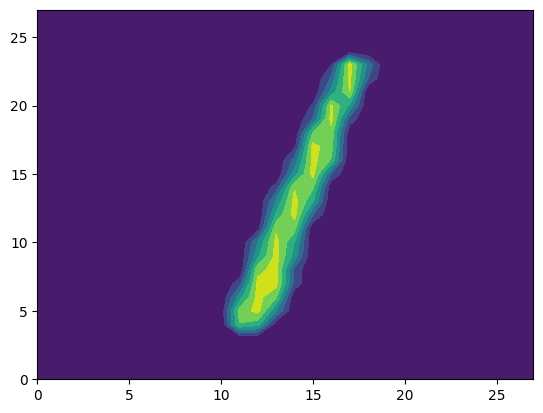

Predicted: 0
True: [0]
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0  11 150 253 202  31   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0  37 251 251 253 107   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  21 197 251 251 253 107   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 110 190 251 251 251 253 169 109  62   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 253 251 251 251

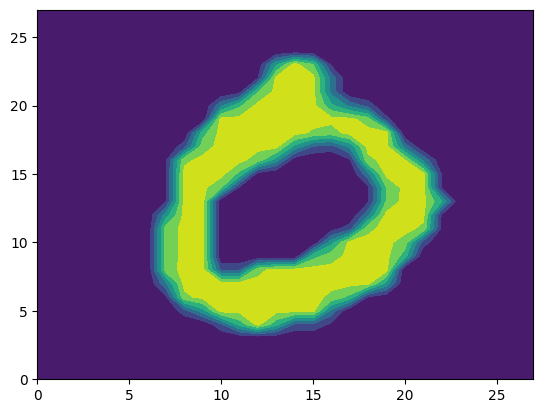

Predicted: 4
True: [4]
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0  50 224   0   0   0   0   0   0   0  70  29   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 121 231   0   0   0   0   0   0   0 148 168   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   4 195 231   0   0   0   0   0   0   0  96 210  11   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0  69 252 134   0   0

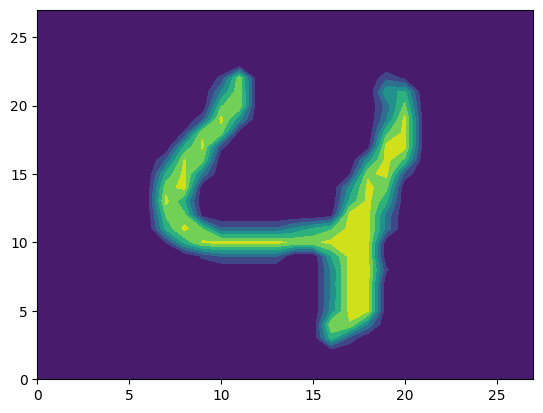

Predicted: 1
True: [1]
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  77 254 107   3   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  19 227 254 254   9   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  81 254 254 165   1   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0

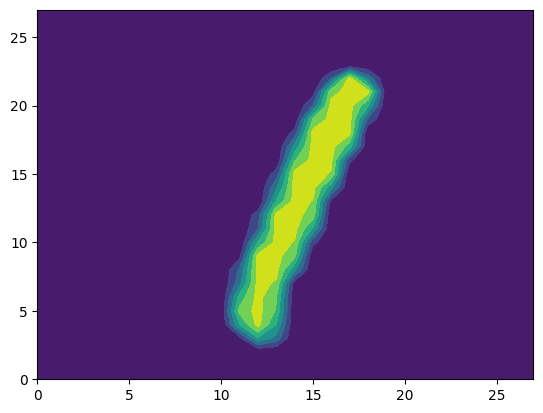

Predicted: 4
True: [4]
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0  22 192 134  32   0   0   0   0   0   0   0   0  15  77   5   0   0   0   0]
 [  0   0   0   0   0   0   0   0  17 235 250 169   0   0   0   0   0   0   0   0  15 220 241  37   0   0   0   0]
 [  0   0   0   0   0   0   0  20 189 253 147   0   0   0   0   0   0   0   0   0 139 253 100   0   0   0   0   0]
 [  0   0   0   0   0   0   0  70 253 253  21   0   0   0

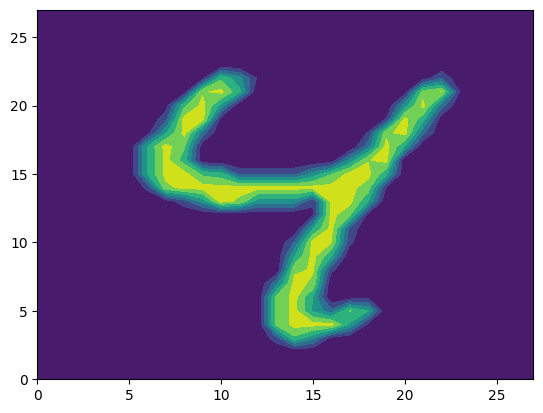

Predicted: 9
True: [9]
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  14 149 193   5   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0  91 224 253 253  19   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0  28 235 254 253 253

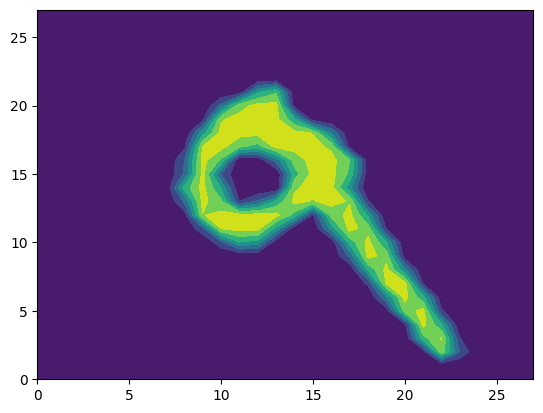

Predicted: 5
True: [5]
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  17  47  47  47  16 129  85  47   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  75 153 217 253 253 253 215 246 253 253   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0  35 142 244 252 253 253 253 253 253 253 253 253 253   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0  63 253 253 253 253 253 253 253 213 170 170 170 170   0   0   0]
 [  0   0   0   0   0   0   0   0  20 132  72   0  57 238

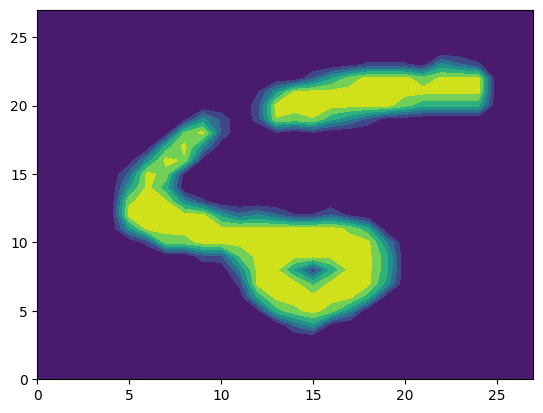

Predicted: 9
True: [9]
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0  36  56 137 201 199  95  37   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  45 152 234

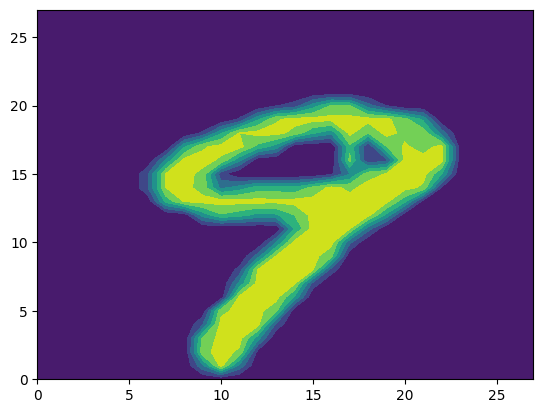

In [40]:
for i in range(10):
    print("Predicted:", y_hat[i])
    print("True:", y_test[i])
    print(X_test[i],'\n')
    plt.contourf(np.rot90(X_test[i].T))
    plt.show()

In [35]:
# Accuracy:
from sklearn.metrics import accuracy_score
print("Test accuracy is", accuracy_score(y_test, y_hat))

Test accuracy is 0.9705


In [36]:
# Confusion matrix with clear row labels to be readable:
import pandas as pd
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_hat)
cm_df = pd.DataFrame(cm)
cm_df

,0,1,2,3,4,5,6,7,8,9
0,974,1,1,0,0,1,2,1,0,0
1,0,1133,2,0,0,0,0,0,0,0
2,10,9,996,2,0,0,0,13,2,0
3,0,2,4,976,1,13,1,7,3,3
4,1,6,0,0,950,0,4,2,0,19
5,6,1,0,11,2,859,5,1,3,4
6,5,3,0,0,3,3,944,0,0,0
7,0,21,5,0,1,0,0,991,0,10
8,8,2,4,16,8,11,3,4,914,4
9,4,5,2,8,9,2,1,8,2,968


6. For your confusion matrix, which mistakes are most likely? Do you find any interesting patterns?

In [ ]:
# It's most likely that 1s get confused with 7s (understandable), 3s with 5s (bizzare) and 8s (understandable), 7s with 2s (I can see it)
# and 9s with 4s (understandable) and 7s (hm).
# I think the general pattern is if two numbers share a similar symmetry (i.e. at the top of the character, they both have left parts
# or at the bottom they both have right parts), they're more likely to be confused with one another.

7. So, this is how computers "see." They convert an image into a matrix of values, that matrix becomes a vector in a dataset, and then we deploy ML tools on it as if it was any other kind of tabular data. To make sure you follow this, invent a way to represent a color photo in matrix form, and then describe how you could convert it into tabular data. (Hint: RGB color codes provide a method of encoding a numeric value that represents a color.)

In [ ]:
# This is pretty cool! So you coud have a matrix of RGB values where
# each RGB value represents a pixel -- basically this is how image files
# work to my understanding! How you could convert this to tabular data would be
# doing exactly what we did -- reshaping from rows and columns just to one long
# list for each obs.